Loading project embedder...


No GPU found. Using lightweight CPU embedder: Alibaba-NLP/gte-Qwen2-1.5B-instruct
Loading embedding model: all-MiniLM-L6-v2


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

/Users/kevincapcha/PycharmProjects/CS195S2026/outputs/cs195-ska-projects/shared/ska_agent-1.0.0-8/ska_agent/models/embedding.py:51: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  self.embedding_dim = self.model.get_sentence_embedding_dimension()


Embedder ready (dim=384)
Created 275 raw segment texts.
Created 100 OfficeQA-style questions.
Question counts by mode:
 LOOKUP: 25
 MULTI_DOC: 25
 COMPUTE: 25
 MULTI_STEP: 25

Embedding segments once...
Created 275 Segment objects.
Embedding dimension: 384

Starting Week 4 lambda sweep...
Processed 25/100 questions...
Processed 50/100 questions...
Processed 75/100 questions...
Processed 100/100 questions...

Generated 800 lambda sweep records.
Saved Week 4 sweep records to: ../outputs/lambda_sweep_baseline.json

Complexity-aligned optimal lambda distribution:
LOOKUP       Counter({0.5: 24, 0.2: 1})
MULTI_DOC    Counter({0.2: 18, 0.5: 4, 0.02: 2, 0.05: 1})
COMPUTE      Counter({0.2: 15, 0.5: 7, 0.02: 2, 0.01: 1})
MULTI_STEP   Counter({0.02: 11, 0.2: 8, 0.5: 3, 0.01: 2, 0.05: 1})


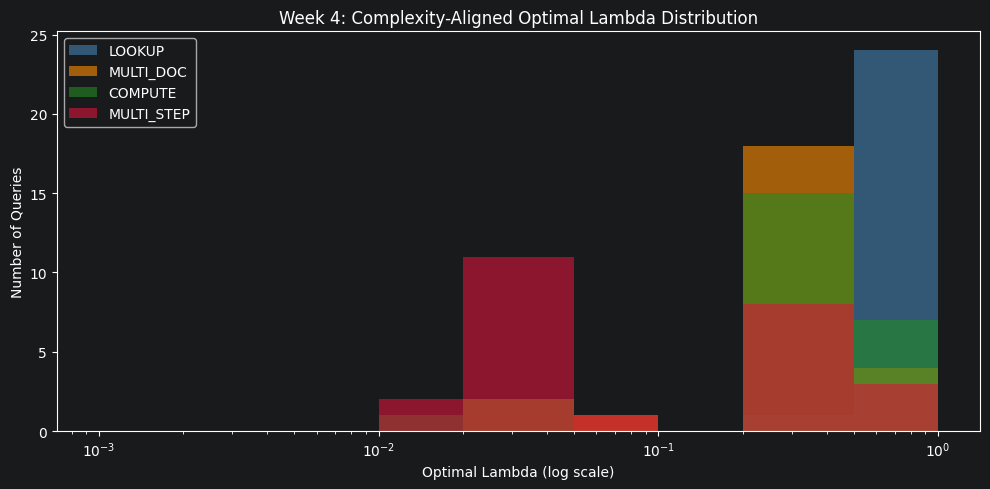

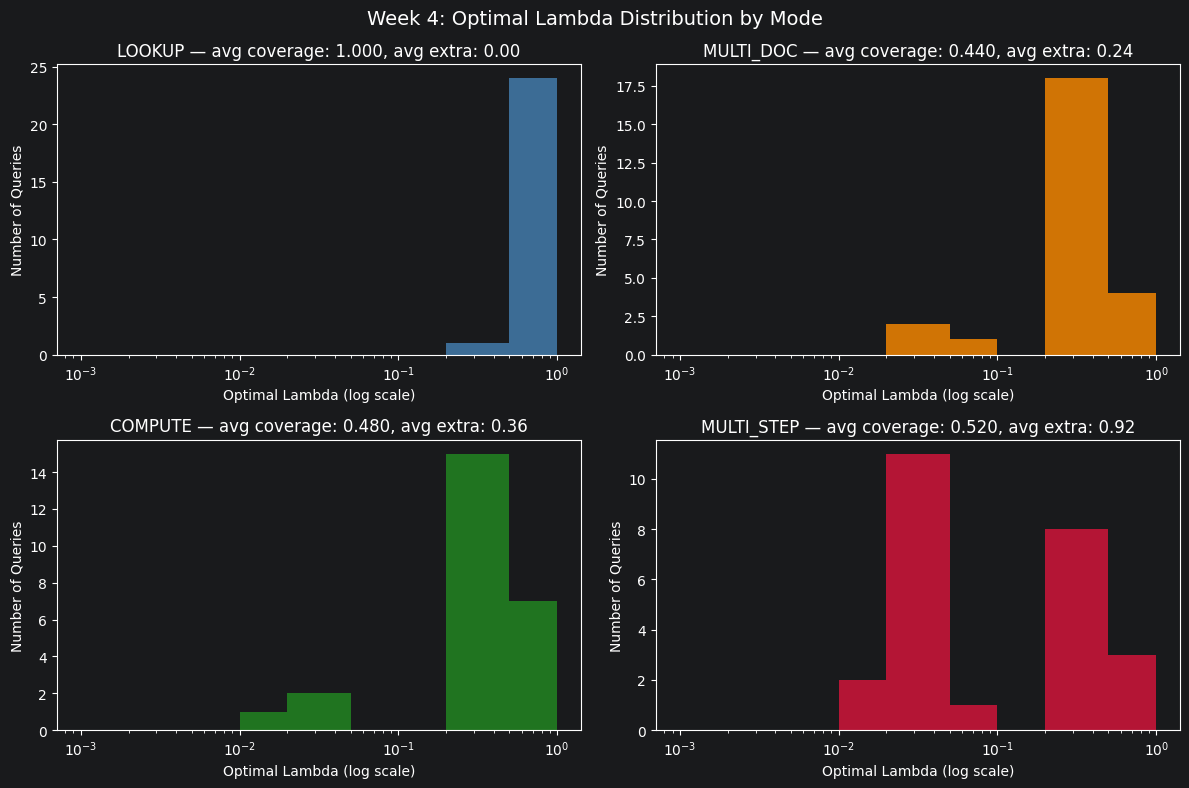

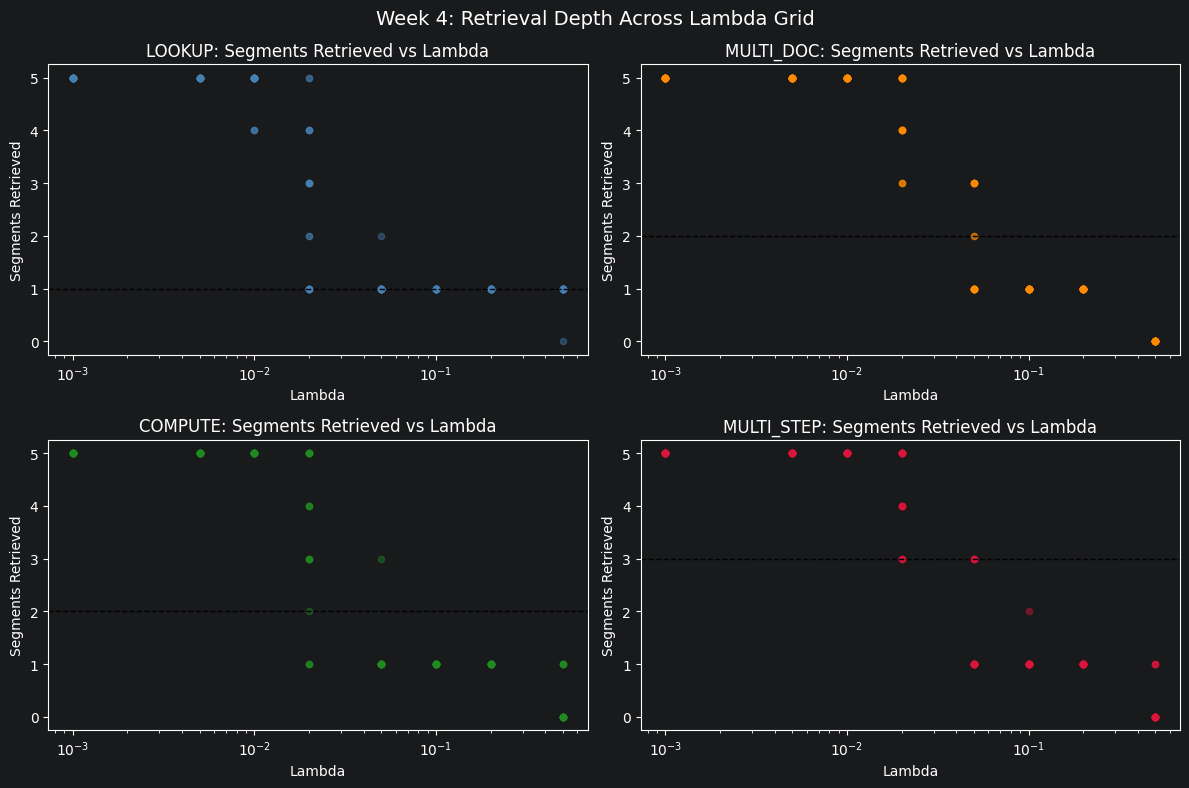


Week 4 Summary:
Mode          TargetK   AvgCov   AvgPrec   AvgRec    AvgF1  AvgExtra   AvgSegs Lambda Dist
-----------------------------------------------------------------------------------------------------------------------------
LOOKUP              1    1.000     1.000    1.000    1.000      0.00      1.00 Counter({0.5: 24, 0.2: 1})
MULTI_DOC           2    0.440     0.764    0.440    0.534      0.24      1.20 Counter({0.2: 18, 0.5: 4, 0.02: 2, 0.05: 1})
COMPUTE             2    0.480     0.864    0.480    0.594      0.36      1.44 Counter({0.2: 15, 0.5: 7, 0.02: 2, 0.01: 1})
MULTI_STEP          3    0.520     0.687    0.520    0.515      0.92      3.04 Counter({0.02: 11, 0.2: 8, 0.5: 3, 0.01: 2, 0.05: 1})

Sample optimal lambdas:
 lookup_0 | LOOKUP | best_lambda=0.5 | coverage=1.000 | target_k=1 | retrieved_relevant=1 | missing=0 | extra=0 | precision=1.000 | recall=1.000 | f1=1.000 | score=1.000 | segments=1
 lookup_1 | LOOKUP | best_lambda=0.5 | coverage=1.000 | target_k=1 | re

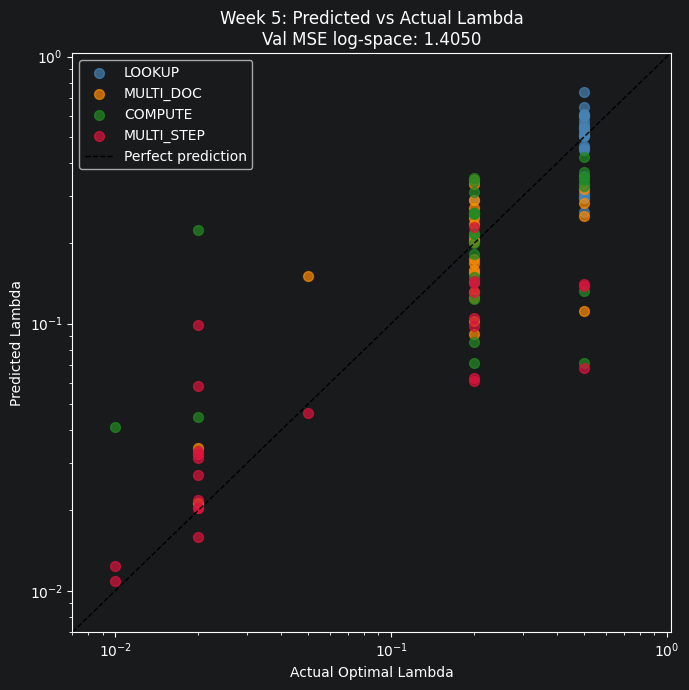

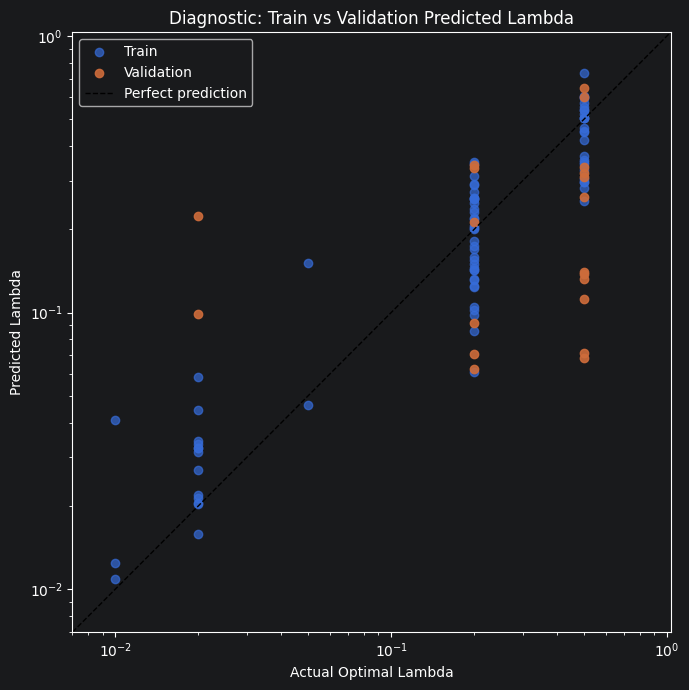

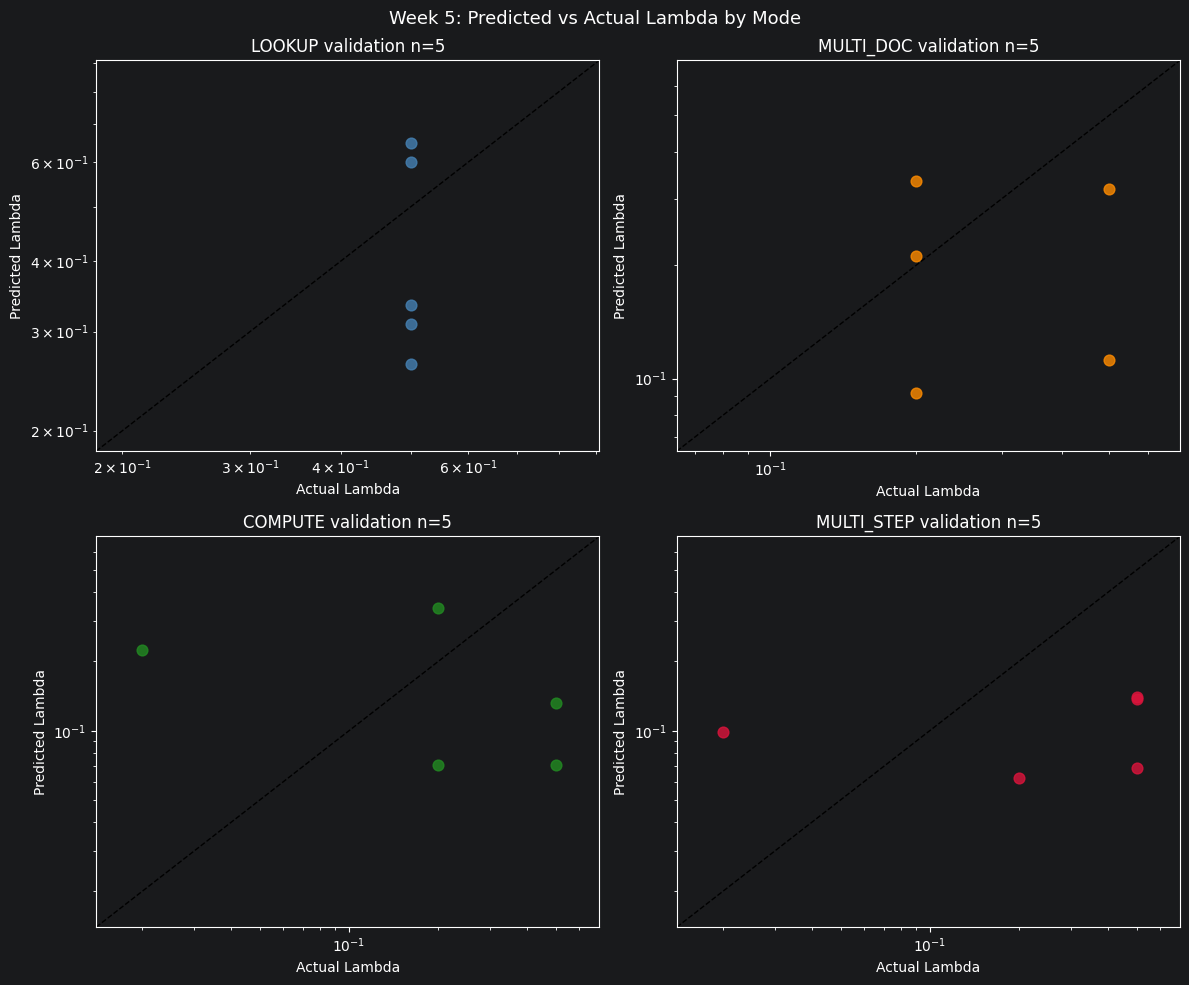

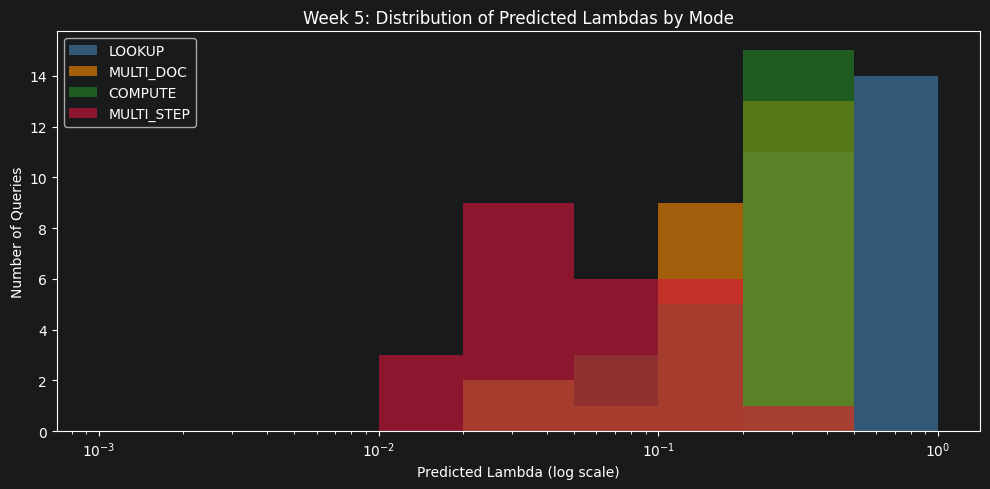

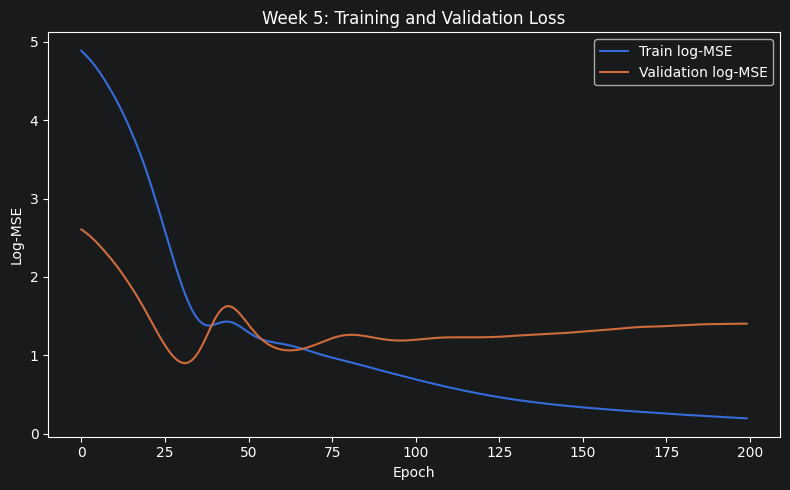

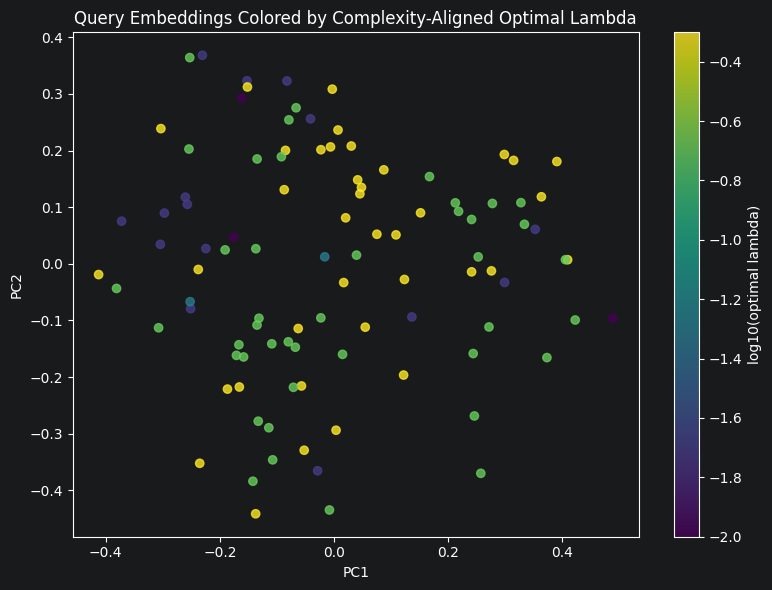


Sample predicted lambdas by mode:

[LOOKUP] What were the reported outlays for Debt Servicing under Treasury Operations Office in 1999?
 actual=0.5000, predicted=0.5063, ratio=1.01x

[LOOKUP] What were the reported outlays for Infrastructure Loans under Public Debt Service in 2000?
 actual=0.5000, predicted=0.5735, ratio=1.15x

[LOOKUP] What were the reported outlays for Agency Payroll under Revenue Analysis Bureau in 2001?
 actual=0.5000, predicted=0.2628, ratio=0.53x

[LOOKUP] What were the reported outlays for Municipal Support under Federal Grants Division in 2002?
 actual=0.5000, predicted=0.6082, ratio=1.22x

[LOOKUP] What were the reported outlays for Technology Modernization under Cash Management Office in 2003?
 actual=0.5000, predicted=0.6001, ratio=1.20x

[MULTI_DOC] Comparing Treasury Operations Office and Federal Grants Division, which agency had larger obligation
 actual=0.2000, predicted=0.0917, ratio=0.46x

[MULTI_DOC] Comparing Public Debt Service and Cash Management 

In [1]:
# Week 4 and 5 Deliverable. Lambda sweep + MLP training pipeline (Weeks 4 & 5)

import os
import sys
import json
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

sys.path.append(os.path.abspath("../cs195-ska-projects/shared/ska_agent-1.0.0-8"))

from ska_agent.core.pricing import PricingEngine
from ska_agent.core.structures import Segment
from ska_agent.models.embedding import Embedder
from ska_agent.evaluation.officeqa import OfficeQAQuestion

EPS = 1e-10
LAMBDA_GRID = [0.001, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.5]
N_PER_MODE = 25
ETA_REDUNDANCY = 0.0
MAX_SEGMENTS = 5
TIE_EPS = 1e-8
OUTPUT_DIR = "../outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

TARGET_K_BY_MODE = {
    "LOOKUP": 1,
    "MULTI_DOC": 2,
    "COMPUTE": 2,
    "MULTI_STEP": 3,
}

MISSING_EVIDENCE_PENALTY = 0.25
EXTRA_SEGMENT_PENALTY = 0.04
WRONG_PICK_PENALTY = 0.02


def ensure_1d(array):
    """Reshape any array into a flat 1D numpy array."""
    arr = np.asarray(array, dtype=np.float64)
    return arr.reshape(-1)


def ensure_2d_rows(array):
    """Ensure the array is 2D with shape (num_rows, num_cols)."""
    arr = np.asarray(array, dtype=np.float64)
    if arr.size == 0:
        return np.empty((0, 0), dtype=np.float64)
    if arr.ndim == 1:
        return arr.reshape(1, -1)
    return arr


def get_selected_embeddings(result):
    """Extract the embedding vectors from all retrieved segments."""
    if not result.segments:
        return np.empty((0, 0), dtype=np.float64)
    embedding_list = [ensure_1d(segment.vector) for segment in result.segments]
    return np.asarray(embedding_list, dtype=np.float64)


def get_selected_indices(result):
    """Extract segment start indices from a PricingEngine result."""
    return [int(seg.start_idx) for seg in result.segments]


def complexity_aligned_lambda_score(selected_indices, relevant_indices, mode):
    """Score lambda based on complexity-aligned evidence coverage."""
    selected_set = set(int(x) for x in selected_indices)
    relevant_set = set(int(x) for x in relevant_indices)

    target_k = TARGET_K_BY_MODE[mode]
    num_selected = len(selected_set)
    num_relevant_retrieved = len(selected_set & relevant_set)

    evidence_coverage = min(num_relevant_retrieved, target_k) / target_k
    missing_evidence = max(0, target_k - num_relevant_retrieved)
    extra_segments = max(0, num_selected - target_k)

    score = (
        evidence_coverage
        - MISSING_EVIDENCE_PENALTY * missing_evidence
        - EXTRA_SEGMENT_PENALTY * extra_segments
        - WRONG_PICK_PENALTY * (num_selected - num_relevant_retrieved)
    )

    precision = 0.0 if num_selected == 0 else num_relevant_retrieved / num_selected
    recall = 0.0 if len(relevant_set) == 0 else num_relevant_retrieved / len(relevant_set)

    if precision + recall < EPS:
        f1 = 0.0
    else:
        f1 = 2.0 * precision * recall / (precision + recall)

    metrics = {
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
        "target_k": int(target_k),
        "num_selected": int(num_selected),
        "num_relevant_retrieved": int(num_relevant_retrieved),
        "missing_evidence": int(missing_evidence),
        "extra_segments": int(extra_segments),
        "evidence_coverage": float(evidence_coverage),
    }
    return float(score), metrics


def dollars(value):
    """Format a number as a dollar string, e.g. 5137 -> '$5,137'."""
    return f"${value:,.0f}"


def make_officeqa_synthetic_corpus(n_per_mode=25):
    """Generate synthetic document segments and questions in OfficeQA style."""
    agencies = [
        "Treasury Operations Office",
        "Public Debt Service",
        "Revenue Analysis Bureau",
        "Federal Grants Division",
        "Cash Management Office",
        "Budget Review Unit",
        "Infrastructure Finance Office",
        "Economic Stabilization Fund",
        "Intergovernmental Transfers Office",
        "Audit and Compliance Division",
        "Fiscal Policy Oversight Bureau",
        "National Revenue Collections Office",
        "Capital Markets Regulation Division",
        "Federal Disbursement Authority",
        "Strategic Reserve Management Office",
        "Debt Issuance and Settlement Bureau",
        "Interagency Coordination Office",
        "Financial Stability Monitoring Unit",
        "Public Investment Accounting Division",
        "Congressional Appropriations Liaison",
        "Municipal Finance Advisory Board",
        "Federal Asset Liquidation Office",
        "Risk and Compliance Analytics Bureau",
        "Sovereign Debt Operations Center",
        "Macroeconomic Policy Analysis Unit",
    ]

    programs = [
        "Debt Servicing",
        "Emergency Grants",
        "Infrastructure Loans",
        "Tax Refund Processing",
        "Agency Payroll",
        "Treasury Securities",
        "Municipal Support",
        "Disaster Relief",
        "Technology Modernization",
        "Public Health Transfers",
        "Capital Investment Funding",
        "Federal Reserve Contributions",
        "Strategic Infrastructure Bonds",
        "Social Safety Net Disbursements",
        "Environmental Compliance Grants",
        "Defense Procurement Transfers",
        "Rural Development Loans",
        "Export Credit Assistance",
        "Pension Obligation Funding",
        "Education Finance Transfers",
        "Cybersecurity Infrastructure",
        "Border Security Allocations",
        "Judicial Operations Funding",
        "Space Program Appropriations",
        "Veterans Benefits Processing",
    ]

    years = list(range(1999, 2025))
    segment_texts = []
    questions = []
    relevant_by_qid = {}

    def add_segment(text):
        idx = len(segment_texts)
        segment_texts.append(text)
        return idx

    # LOOKUP
    for i in range(n_per_mode):
        agency = agencies[i % len(agencies)]
        program = programs[(i * 2) % len(programs)]
        year = years[i % len(years)]
        outlay = 5000 + 137 * i
        answer = dollars(outlay)

        record_idx = add_segment(
            f"[NODE: lookup_{i}_record] type=row | Year: {year} | Agency: {agency} | "
            f"Program: {program} | Outlays: {answer} | "
            f"The reported outlays for {program} under {agency} in {year} were {answer}."
        )
        add_segment(
            f"[NODE: lookup_{i}_distractor] type=note | Year: {year - 1} | Agency: {agency} | "
            f"Category: Administrative Overhead | Internal reference only. "
            f"Do not use for budget reporting."
        )

        qid = f"lookup_{i}"
        questions.append(
            OfficeQAQuestion(
                question_id=qid,
                question=f"What were the reported outlays for {program} under {agency} in {year}?",
                answer=answer,
                source_documents=[f"{agency}_{year}.pdf"],
                question_type="LOOKUP",
                difficulty="easy",
            )
        )
        relevant_by_qid[qid] = [record_idx]

    # MULTI_DOC
    for i in range(n_per_mode):
        agency_a = agencies[i % len(agencies)]
        agency_b = agencies[(i + 3) % len(agencies)]
        program = programs[(i + 1) % len(programs)]
        year = years[i % len(years)]
        value_a = 7000 + 91 * i
        value_b = 6500 + 83 * i
        answer = agency_a if value_a > value_b else agency_b

        doc_a_idx = add_segment(
            f"[NODE: multidoc_{i}_doc_a] type=row | Source: Bulletin A | Year: {year} | "
            f"Agency: {agency_a} | Program: {program} | Obligations: {dollars(value_a)}."
        )
        doc_b_idx = add_segment(
            f"[NODE: multidoc_{i}_doc_b] type=row | Source: Bulletin B | Year: {year} | "
            f"Agency: {agency_b} | Program: {program} | Obligations: {dollars(value_b)}."
        )

        qid = f"multidoc_{i}"
        questions.append(
            OfficeQAQuestion(
                question_id=qid,
                question=(
                    f"Comparing {agency_a} and {agency_b}, which agency had larger obligations "
                    f"for {program} in {year}?"
                ),
                answer=answer,
                source_documents=[f"{agency_a}_{year}.pdf", f"{agency_b}_{year}.pdf"],
                question_type="MULTI_DOC",
                difficulty="medium",
            )
        )
        relevant_by_qid[qid] = [doc_a_idx, doc_b_idx]

    # COMPUTE
    for i in range(n_per_mode):
        agency = agencies[(i + 2) % len(agencies)]
        program = programs[(i + 4) % len(programs)]
        year_a = years[i % len(years)]
        year_b = year_a + 1 if year_a < 2024 else 2024
        base_receipts = 10000 + 111 * i
        new_receipts = base_receipts + 250 + 13 * (i % 9)
        difference = new_receipts - base_receipts
        answer = dollars(difference)

        year_a_idx = add_segment(
            f"[NODE: compute_{i}_year_a] type=row | Year: {year_a} | Agency: {agency} | "
            f"Program: {program} | Receipts: {dollars(base_receipts)}."
        )
        year_b_idx = add_segment(
            f"[NODE: compute_{i}_year_b] type=row | Year: {year_b} | Agency: {agency} | "
            f"Program: {program} | Receipts: {dollars(new_receipts)}."
        )

        qid = f"compute_{i}"
        questions.append(
            OfficeQAQuestion(
                question_id=qid,
                question=(
                    f"What was the increase in receipts for {program} under {agency} "
                    f"from {year_a} to {year_b}?"
                ),
                answer=answer,
                source_documents=[f"{agency}_{year_a}.pdf", f"{agency}_{year_b}.pdf"],
                question_type="COMPUTE",
                difficulty="medium",
            )
        )
        relevant_by_qid[qid] = [year_a_idx, year_b_idx]

    # MULTI_STEP
    for i in range(n_per_mode):
        agency = agencies[(i + 5) % len(agencies)]
        program_a = programs[i % len(programs)]
        program_b = programs[(i + 5) % len(programs)]
        year = years[i % len(years)]
        amount_a = 8000 + 101 * i
        amount_b = 8500 + 77 * i
        total = amount_a + amount_b
        answer = dollars(total)

        classification_idx = add_segment(
            f"[NODE: multistep_{i}_classification] type=metadata | Year: {year} | "
            f"Agency: {agency} | Priority programs: {program_a}; {program_b}."
        )
        program_a_idx = add_segment(
            f"[NODE: multistep_{i}_program_a] type=row | Year: {year} | Agency: {agency} | "
            f"Program: {program_a} | Priority Outlays: {dollars(amount_a)}."
        )
        program_b_idx = add_segment(
            f"[NODE: multistep_{i}_program_b] type=row | Year: {year} | Agency: {agency} | "
            f"Program: {program_b} | Priority Outlays: {dollars(amount_b)}."
        )

        qid = f"multistep_{i}"
        questions.append(
            OfficeQAQuestion(
                question_id=qid,
                question=(
                    f"For {agency} in {year}, what were the combined priority outlays "
                    f"for {program_a} and {program_b}?"
                ),
                answer=answer,
                source_documents=[f"{agency}_{year}_priority.pdf"],
                question_type="MULTI_STEP",
                difficulty="hard",
            )
        )
        relevant_by_qid[qid] = [classification_idx, program_a_idx, program_b_idx]

    for i in range(50):
        agency = agencies[i % len(agencies)]
        program = programs[(i + 6) % len(programs)]
        year = years[i % len(years)]
        value = 3000 + 211 * i
        add_segment(
            f"[NODE: distractor_{i}] type=note | Year: {year} | Agency: {agency} | "
            f"Program: {program} | Administrative note value: {dollars(value)} | "
            f"This note is background context and is not the final answer for the training questions."
        )

    return segment_texts, questions, relevant_by_qid

print("Loading project embedder...")
embedder = Embedder(model_name="all-MiniLM-L6-v2")
segment_texts, questions, relevant_by_qid = make_officeqa_synthetic_corpus(n_per_mode=N_PER_MODE)


print(f"Created {len(segment_texts)} raw segment texts.")
print(f"Created {len(questions)} OfficeQA-style questions.")

mode_counts = Counter(q.question_type for q in questions)
print("Question counts by mode:")
for mode, count in mode_counts.items():
    print(f" {mode}: {count}")

print("\nEmbedding segments once...")
segment_vectors = embedder.embed(segment_texts)

segments = []
for i, (text, vec) in enumerate(zip(segment_texts, segment_vectors)):
    vec = np.asarray(vec, dtype=np.float64)
    seg = Segment(
        text=text,
        vector=vec,
        start_idx=i,
        end_idx=i + 1,
        sentences=[text],
        internal_cost=0.0,
    )
    segments.append(seg)

print(f"Created {len(segments)} Segment objects.")
print(f"Embedding dimension: {segments[0].vector.shape[0]}")

def generate_lambda_sweep_records(segments, questions, relevant_by_qid, embed_fn):
    """For each question, sweep lambda over LAMBDA_GRID."""
    records = []

    query_embedding_cache = {}
    for question in questions:
        query_embedding_cache[question.question] = ensure_1d(embed_fn(question.question))

    def cached_embed_fn(text):
        if text in query_embedding_cache:
            return query_embedding_cache[text]
        return ensure_1d(embed_fn(text))

    engines = {
        lam: PricingEngine(
            segments=segments,
            embed_fn=cached_embed_fn,
            lambda_sparsity=lam,
            eta_redundancy=ETA_REDUNDANCY,
            max_segments=MAX_SEGMENTS,
        )
        for lam in LAMBDA_GRID
    }

    for idx, question in enumerate(questions, start=1):
        qid = question.question_id
        query_text = question.question
        relevant_indices = relevant_by_qid[qid]
        records_for_this_query = []

        best_score = -float("inf")
        best_index = 0
        best_num_segments = None
        best_lambda = None

        for lam in LAMBDA_GRID:
            engine = engines[lam]
            result = engine.retrieve(query_text, verbose=False)
            selected_indices = get_selected_indices(result)
            selected_texts = [seg.text for seg in result.segments]

            final_score, metrics = complexity_aligned_lambda_score(
                selected_indices=selected_indices,
                relevant_indices=relevant_indices,
                mode=question.question_type,
            )

            if result.reduced_costs is not None and len(result.reduced_costs) > 0:
                total_reduced_cost = float(np.sum(result.reduced_costs))
            else:
                total_reduced_cost = 0.0

            row = {
                "question_id": qid,
                "query": query_text,
                "mode": question.question_type,
                "difficulty": question.difficulty,
                "gold_answer": question.answer,
                "lambda": float(lam),
                "num_segments": int(len(result.segments)),
                "total_reduced_cost": total_reduced_cost,
                "target_k": metrics["target_k"],
                "num_selected": metrics["num_selected"],
                "num_relevant_retrieved": metrics["num_relevant_retrieved"],
                "missing_evidence": metrics["missing_evidence"],
                "extra_segments": metrics["extra_segments"],
                "evidence_coverage": metrics["evidence_coverage"],
                "retrieval_precision": metrics["precision"],
                "retrieval_recall": metrics["recall"],
                "retrieval_f1": metrics["f1"],
                "relevant_segment_indices": [int(x) for x in relevant_indices],
                "selected_segment_indices": selected_indices,
                "selected_segment_texts": selected_texts,
                "final_lambda_score": float(final_score),
                "is_optimal": False,
            }
            records_for_this_query.append(row)

            num_segments = len(result.segments)
            if final_score > best_score + TIE_EPS:
                best_score = final_score
                best_index = len(records_for_this_query) - 1
                best_num_segments = num_segments
                best_lambda = lam
            elif abs(final_score - best_score) <= TIE_EPS:
                if best_num_segments is None or num_segments < best_num_segments:
                    best_score = final_score
                    best_index = len(records_for_this_query) - 1
                    best_num_segments = num_segments
                    best_lambda = lam
                elif num_segments == best_num_segments and best_lambda is not None and lam > best_lambda:
                    best_score = final_score
                    best_index = len(records_for_this_query) - 1
                    best_num_segments = num_segments
                    best_lambda = lam

        records_for_this_query[best_index]["is_optimal"] = True
        records.extend(records_for_this_query)

        if idx % 25 == 0:
            print(f"Processed {idx}/{len(questions)} questions...")

    return records


print("\nStarting Week 4 lambda sweep...")
records = generate_lambda_sweep_records(
    segments=segments,
    questions=questions,
    relevant_by_qid=relevant_by_qid,
    embed_fn=embedder.embed_single,
)

print(f"\nGenerated {len(records)} lambda sweep records.")
assert len(records) == len(questions) * len(LAMBDA_GRID)

json_path = os.path.join(OUTPUT_DIR, "lambda_sweep_baseline.json")
with open(json_path, "w", encoding="utf-8") as f:
    json.dump(records, f, indent=2)
print(f"Saved Week 4 sweep records to: {json_path}")

modes = ["LOOKUP", "MULTI_DOC", "COMPUTE", "MULTI_STEP"]
mode_colors = {
    "LOOKUP": "steelblue",
    "MULTI_DOC": "darkorange",
    "COMPUTE": "forestgreen",
    "MULTI_STEP": "crimson",
}
lambda_bins = [0.001, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1.0]
optimal_records = [r for r in records if r["is_optimal"]]
optimal_lambdas = [r["lambda"] for r in optimal_records]

print("\nComplexity-aligned optimal lambda distribution:")
for mode in modes:
    vals = [r["lambda"] for r in optimal_records if r["mode"] == mode]
    print(f"{mode:<12} {Counter(vals)}")

fig, ax = plt.subplots(figsize=(10, 5))
for mode in modes:
    mode_lambdas = [r["lambda"] for r in optimal_records if r["mode"] == mode]
    ax.hist(mode_lambdas, bins=lambda_bins, alpha=0.6, label=mode, color=mode_colors[mode])
ax.set_xscale("log")
ax.set_xlabel("Optimal Lambda (log scale)")
ax.set_ylabel("Number of Queries")
ax.set_title("Week 4: Complexity-Aligned Optimal Lambda Distribution")
ax.legend()
plt.tight_layout()
hist_path = os.path.join(OUTPUT_DIR, "week4_complexity_aligned_optimal_lambda_distribution.png")
plt.savefig(hist_path, dpi=200)
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for ax, mode in zip(axes, modes):
    mode_lambdas = [r["lambda"] for r in optimal_records if r["mode"] == mode]
    avg_coverage = np.mean([r["evidence_coverage"] for r in optimal_records if r["mode"] == mode])
    avg_extra = np.mean([r["extra_segments"] for r in optimal_records if r["mode"] == mode])
    ax.hist(mode_lambdas, bins=lambda_bins, color=mode_colors[mode], alpha=0.8)
    ax.set_xscale("log")
    ax.set_xlabel("Optimal Lambda (log scale)")
    ax.set_ylabel("Number of Queries")
    ax.set_title(f"{mode} — avg coverage: {avg_coverage:.3f}, avg extra: {avg_extra:.2f}")
plt.suptitle("Week 4: Optimal Lambda Distribution by Mode", fontsize=14)
plt.tight_layout()
mode_hist_path = os.path.join(OUTPUT_DIR, "week4_complexity_aligned_lambda_by_mode.png")
plt.savefig(mode_hist_path, dpi=200)
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for ax, mode in zip(axes, modes):
    for lam in LAMBDA_GRID:
        seg_counts = [r["num_segments"] for r in records if r["mode"] == mode and r["lambda"] == lam]
        ax.scatter([lam] * len(seg_counts), seg_counts, alpha=0.4, color=mode_colors[mode], s=20)
    ax.axhline(TARGET_K_BY_MODE[mode], linestyle="--", linewidth=1, color="black")
    ax.set_xscale("log")
    ax.set_xlabel("Lambda")
    ax.set_ylabel("Segments Retrieved")
    ax.set_title(f"{mode}: Segments Retrieved vs Lambda")
plt.suptitle("Week 4: Retrieval Depth Across Lambda Grid", fontsize=14)
plt.tight_layout()
depth_path = os.path.join(OUTPUT_DIR, "week4_retrieval_depth_by_lambda.png")
plt.savefig(depth_path, dpi=200)
plt.show()

print("\nWeek 4 Summary:")
print(
    f"{'Mode':<12} {'TargetK':>8} {'AvgCov':>8} {'AvgPrec':>9} "
    f"{'AvgRec':>8} {'AvgF1':>8} {'AvgExtra':>9} {'AvgSegs':>9} {'Lambda Dist'}"
)
print("-" * 125)
for mode in modes:
    optimal_for_mode = [r for r in optimal_records if r["mode"] == mode]
    avg_coverage = np.mean([r["evidence_coverage"] for r in optimal_for_mode])
    avg_precision = np.mean([r["retrieval_precision"] for r in optimal_for_mode])
    avg_recall = np.mean([r["retrieval_recall"] for r in optimal_for_mode])
    avg_f1 = np.mean([r["retrieval_f1"] for r in optimal_for_mode])
    avg_extra = np.mean([r["extra_segments"] for r in optimal_for_mode])
    avg_segments = np.mean([r["num_segments"] for r in optimal_for_mode])
    lambda_dist = Counter([r["lambda"] for r in optimal_for_mode])
    print(
        f"{mode:<12} "
        f"{TARGET_K_BY_MODE[mode]:>8} "
        f"{avg_coverage:>8.3f} "
        f"{avg_precision:>9.3f} "
        f"{avg_recall:>8.3f} "
        f"{avg_f1:>8.3f} "
        f"{avg_extra:>9.2f} "
        f"{avg_segments:>9.2f} "
        f"{lambda_dist}"
    )

print("\nSample optimal lambdas:")
num_shown = 0
for r in optimal_records:
    print(
        f" {r['question_id']} | {r['mode']} | "
        f"best_lambda={r['lambda']} | "
        f"coverage={r['evidence_coverage']:.3f} | "
        f"target_k={r['target_k']} | "
        f"retrieved_relevant={r['num_relevant_retrieved']} | "
        f"missing={r['missing_evidence']} | "
        f"extra={r['extra_segments']} | "
        f"precision={r['retrieval_precision']:.3f} | "
        f"recall={r['retrieval_recall']:.3f} | "
        f"f1={r['retrieval_f1']:.3f} | "
        f"score={r['final_lambda_score']:.3f} | "
        f"segments={r['num_segments']}"
    )
    num_shown += 1
    if num_shown >= 20:
        break


def build_training_dataset(records, embed_fn):
    """Convert optimal Week 4 records into MLP training data."""
    optimal = [r for r in records if r["is_optimal"]]
    queries = [r["query"] for r in optimal]
    modes = [r["mode"] for r in optimal]
    y = np.asarray([r["lambda"] for r in optimal], dtype=np.float32)
    embeddings = []
    for query in queries:
        emb = ensure_1d(embed_fn(query))
        embeddings.append(emb)
    X = np.asarray(embeddings, dtype=np.float32)
    return X, y, queries, modes


def stratified_train_val_split(X, y, modes, val_frac=0.2, seed=0):
    """Stratify by query mode so validation has examples from each mode."""
    rng = np.random.default_rng(seed)
    modes_arr = np.asarray(modes)
    train_idx = []
    val_idx = []

    for mode in sorted(set(modes)):
        mode_indices = np.where(modes_arr == mode)[0]
        rng.shuffle(mode_indices)
        n_val = max(1, int(len(mode_indices) * val_frac))
        val_idx.extend(mode_indices[:n_val])
        train_idx.extend(mode_indices[n_val:])

    train_idx = np.asarray(train_idx)
    val_idx = np.asarray(val_idx)
    rng.shuffle(train_idx)
    rng.shuffle(val_idx)

    return (
        X[train_idx],
        X[val_idx],
        y[train_idx],
        y[val_idx],
        train_idx,
        val_idx,
    )


class LambdaPredictor(nn.Module):
    """Small MLP that predicts log(lambda) from a query embedding."""

    def __init__(self, input_dim, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)


print("\nBuilding Week 5 training dataset...")
X, y, optimal_queries, optimal_modes = build_training_dataset(records=records, embed_fn=embedder.embed_single)
X_train, X_val, y_train, y_val, train_idx, val_idx = stratified_train_val_split(
    X=X,
    y=y,
    modes=optimal_modes,
    val_frac=0.2,
    seed=0,
)

print("\nWeek 5 dataset shapes:")
print(f" X_train: {X_train.shape}")
print(f" y_train: {y_train.shape}")
print(f" X_val: {X_val.shape}")
print(f" y_val: {y_val.shape}")
input_dim = X_train.shape[1]
print(f" input_dim: {input_dim}")

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_log_tensor = torch.tensor(np.log(np.clip(y_train, EPS, None)), dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_log_tensor = torch.tensor(np.log(np.clip(y_val, EPS, None)), dtype=torch.float32)

model = LambdaPredictor(input_dim=input_dim, hidden_dim=64)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
num_epochs = 200

print("\nStarting Week 5 MLP training...")
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()
    predicted_train_log = model(X_train_tensor)
    train_loss = criterion(predicted_train_log, y_train_log_tensor)
    train_loss.backward()
    optimizer.step()
    train_losses.append(float(train_loss.item()))

    model.eval()
    with torch.no_grad():
        predicted_val_log = model(X_val_tensor)
        val_loss = criterion(predicted_val_log, y_val_log_tensor)
        val_losses.append(float(val_loss.item()))

    if epoch % 50 == 0 or epoch == num_epochs - 1:
        print(
            f"Epoch {epoch:03d} | "
            f"train log-MSE = {train_loss.item():.6f} | "
            f"val log-MSE = {val_loss.item():.6f}"
        )

model.eval()
with torch.no_grad():
    pred_train_log = model(X_train_tensor)
    pred_val_log = model(X_val_tensor)
    train_mse = criterion(pred_train_log, y_train_log_tensor).item()
    val_mse = criterion(pred_val_log, y_val_log_tensor).item()
    pred_train = torch.exp(pred_train_log).numpy()
    pred_val = torch.exp(pred_val_log).numpy()

print(f"\nTraining MSE on log(lambda): {train_mse}")
print(f"Validation MSE on log(lambda): {val_mse}")

with torch.no_grad():
    X_all_tensor = torch.tensor(X, dtype=torch.float32)
    all_preds = torch.exp(model(X_all_tensor)).numpy()

optimal_modes_arr = np.asarray(optimal_modes)

fig, ax = plt.subplots(figsize=(7, 7))
for mode in modes:
    mode_mask = optimal_modes_arr == mode
    ax.scatter(y[mode_mask], all_preds[mode_mask], label=mode, color=mode_colors[mode], alpha=0.7, s=50)
all_vals = np.concatenate([y, all_preds])
lower = max(all_vals.min() * 0.7, 1e-5)
upper = all_vals.max() * 1.4
ax.plot([lower, upper], [lower, upper], "k--", linewidth=1, label="Perfect prediction")
ax.set_xlim([lower, upper])
ax.set_ylim([lower, upper])
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Actual Optimal Lambda")
ax.set_ylabel("Predicted Lambda")
ax.set_title(f"Week 5: Predicted vs Actual Lambda\nVal MSE log-space: {val_mse:.4f}")
ax.legend()
plt.tight_layout()
pred_path = os.path.join(OUTPUT_DIR, "week5_predicted_vs_actual_lambda.png")
plt.savefig(pred_path, dpi=200)
plt.show()

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_train, pred_train, label="Train", alpha=0.7)
ax.scatter(y_val, pred_val, label="Validation", alpha=0.9)
all_vals = np.concatenate([y_train, y_val, pred_train, pred_val])
lower = max(all_vals.min() * 0.7, 1e-5)
upper = all_vals.max() * 1.4
ax.plot([lower, upper], [lower, upper], "k--", linewidth=1, label="Perfect prediction")
ax.set_xlim([lower, upper])
ax.set_ylim([lower, upper])
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Actual Optimal Lambda")
ax.set_ylabel("Predicted Lambda")
ax.set_title("Diagnostic: Train vs Validation Predicted Lambda")
ax.legend()
plt.tight_layout()
train_val_pred_path = os.path.join(OUTPUT_DIR, "week5_train_vs_validation_prediction.png")
plt.savefig(train_val_pred_path, dpi=200)
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
val_modes = np.asarray([optimal_modes[i] for i in val_idx])
for ax, mode in zip(axes, modes):
    mode_mask = val_modes == mode
    actuals_mode = y_val[mode_mask]
    preds_mode = pred_val[mode_mask]
    if len(actuals_mode) == 0:
        ax.set_title(f"{mode} — no validation samples")
        continue
    ax.scatter(actuals_mode, preds_mode, color=mode_colors[mode], alpha=0.8, s=60)
    local_vals = np.concatenate([actuals_mode, preds_mode])
    lower = max(local_vals.min() * 0.7, 1e-5)
    upper = local_vals.max() * 1.4
    ax.plot([lower, upper], [lower, upper], "k--", linewidth=1)
    ax.set_xlim([lower, upper])
    ax.set_ylim([lower, upper])
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Actual Lambda")
    ax.set_ylabel("Predicted Lambda")
    ax.set_title(f"{mode} validation n={sum(mode_mask)}")
plt.suptitle("Week 5: Predicted vs Actual Lambda by Mode", fontsize=13)
plt.tight_layout()
pred_mode_path = os.path.join(OUTPUT_DIR, "week5_predicted_vs_actual_by_mode.png")
plt.savefig(pred_mode_path, dpi=200)
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
for mode in modes:
    mode_mask = optimal_modes_arr == mode
    ax.hist(all_preds[mode_mask], bins=lambda_bins, alpha=0.6, label=mode, color=mode_colors[mode])
ax.set_xscale("log")
ax.set_xlabel("Predicted Lambda (log scale)")
ax.set_ylabel("Number of Queries")
ax.set_title("Week 5: Distribution of Predicted Lambdas by Mode")
ax.legend()
plt.tight_layout()
pred_dist_path = os.path.join(OUTPUT_DIR, "week5_predicted_lambda_distribution.png")
plt.savefig(pred_dist_path, dpi=200)
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_losses, label="Train log-MSE")
ax.plot(val_losses, label="Validation log-MSE")
ax.set_xlabel("Epoch")
ax.set_ylabel("Log-MSE")
ax.set_title("Week 5: Training and Validation Loss")
ax.legend()
plt.tight_layout()
loss_path = os.path.join(OUTPUT_DIR, "week5_training_validation_loss.png")
plt.savefig(loss_path, dpi=200)
plt.show()

try:
    from sklearn.decomposition import PCA

    pca = PCA(n_components=2)
    X_2d = pca.fit_transform(X)
    fig, ax = plt.subplots(figsize=(8, 6))
    scatter = ax.scatter(X_2d[:, 0], X_2d[:, 1], c=np.log10(y), alpha=0.8)
    plt.colorbar(scatter, ax=ax, label="log10(optimal lambda)")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_title("Query Embeddings Colored by Complexity-Aligned Optimal Lambda")
    plt.tight_layout()
    pca_path = os.path.join(OUTPUT_DIR, "week5_pca_query_embeddings_by_optimal_lambda.png")
    plt.savefig(pca_path, dpi=200)
    plt.show()
except ImportError:
    pca_path = None
    print("\nSkipping PCA diagnostic because scikit-learn is not installed.")

print("\nSample predicted lambdas by mode:")
shown_per_mode = {mode: 0 for mode in modes}
for query, mode, actual, pred in zip(optimal_queries, optimal_modes, y, all_preds):
    if shown_per_mode[mode] < 5:
        print(f"\n[{mode}] {query[:100]}")
        print(f" actual={actual:.4f}, predicted={pred:.4f}, ratio={pred / actual:.2f}x")
    shown_per_mode[mode] += 1
    if all(count >= 5 for count in shown_per_mode.values()):
        break

checkpoint_path = os.path.join(OUTPUT_DIR, "lambda_predictor_week5_checkpoint.pt")
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "input_dim": input_dim,
        "hidden_dim": 64,
        "train_mse": train_mse,
        "val_mse": val_mse,
        "lambda_grid": LAMBDA_GRID,
        "target_k_by_mode": TARGET_K_BY_MODE,
        "missing_evidence_penalty": MISSING_EVIDENCE_PENALTY,
        "extra_segment_penalty": EXTRA_SEGMENT_PENALTY,
        "max_segments": MAX_SEGMENTS,
        "eta_redundancy": ETA_REDUNDANCY,
    },
    checkpoint_path,
)

print("\nSaved files:")
print(f" Week 4 JSON: {json_path}")
print(f" Week 4 optimal lambda histogram: {hist_path}")
print(f" Week 4 optimal lambda by mode: {mode_hist_path}")
print(f" Week 4 retrieval depth plot: {depth_path}")
print(f" Week 5 predicted vs actual: {pred_path}")
print(f" Week 5 train vs validation prediction: {train_val_pred_path}")
print(f" Week 5 predicted vs actual by mode: {pred_mode_path}")
print(f" Week 5 predicted lambda distribution: {pred_dist_path}")
print(f" Week 5 loss curve: {loss_path}")
if pca_path is not None:
    print(f" Week 5 PCA diagnostic: {pca_path}")
print(f" Week 5 checkpoint: {checkpoint_path}")